<a href="https://colab.research.google.com/github/rishan005/colab-notebook/blob/main/california_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
import pandas as pd

In [ ]:
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [ ]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
col = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households','median_income','median_house_value']

for i in col:
  df[i]=sc.fit_transform(df[[i]])


In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,2.619365,-0.671520,-1.079671,1.361695,1.764204,-0.361184,-0.075998,-1.252543,-1.210558
1,2.539569,-0.573264,-0.761872,2.296608,3.230441,-0.261865,-0.099404,-1.081483,-1.096745
2,2.494683,-0.905463,-0.920772,-0.882462,-0.866956,-0.955354,-0.999252,-1.170105,-1.048461
3,2.489696,-0.928857,-1.159121,-0.524186,-0.480230,-0.796793,-0.715774,-0.362600,-1.154514
4,2.489696,-0.961609,-0.682422,-0.545747,-0.506328,-0.701830,-0.622148,-1.026454,-1.222629


In [ ]:
x=df.drop('median_house_value',axis=1)
y= df['median_house_value']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
import tensorflow as tf

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='linear'),
])

In [ ]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [ ]:
history = model.fit(x_train,y_train,validation_data=[x_test,y_test],epochs=20)

Epoch 1/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5322 - mae: 0.5477 - val_loss: 0.2841 - val_mae: 0.3847
Epoch 2/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2917 - mae: 0.3891 - val_loss: 0.2672 - val_mae: 0.3698
Epoch 3/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2705 - mae: 0.3718 - val_loss: 0.2505 - val_mae: 0.3531
Epoch 4/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2613 - mae: 0.3603 - val_loss: 0.2517 - val_mae: 0.3495
Epoch 5/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2448 - mae: 0.3490 - val_loss: 0.2417 - val_mae: 0.3470
Epoch 6/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2362 - mae: 0.3428 - val_loss: 0.2293 - val_mae: 0.3396
Epoch 7/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2365 - mae: 0.3420 - val_loss: 0.2339 - val_mae: 0.3457
Epoch 8/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2239 - mae: 0.3326 - val_loss: 0.2247 - val_mae: 0.3325
Epoch 9/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

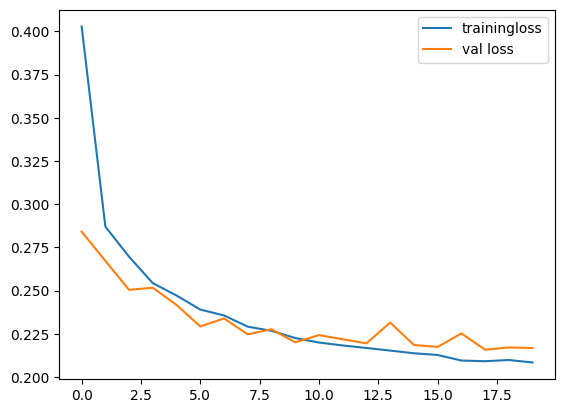

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='trainingloss')
plt.plot(history.history['val_loss'],label='val loss')
plt.legend()
plt.show()